In [1]:
from torchvision import datasets , transforms

In [2]:
!pip install torch torchvision


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
transforms.ToTensor()

ToTensor()

In [4]:
transform = transforms.ToTensor()

In [5]:
train_dataset = datasets.MNIST(root = "./data" , train = True , download= True , transform = transform )

In [6]:
print(len(train_dataset))

60000


In [7]:
image , label = train_dataset[45]

print(image.shape)
print(label)

torch.Size([1, 28, 28])
9


## Let's display the image

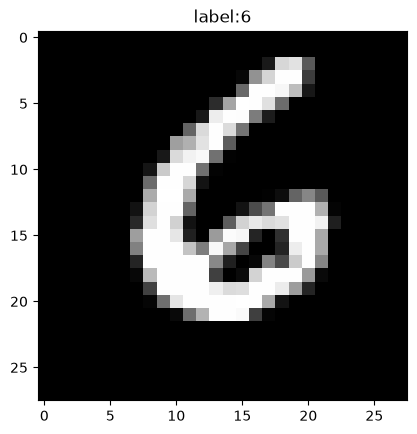

In [8]:
import matplotlib.pyplot as plt

image, label = train_dataset[90]

plt.imshow(image.squeeze(),cmap = "gray")
plt.title(f"label:{label}")
plt.show()

### We will use dataloader to get group of images in a batch 

In [9]:
from torch.utils.data import DataLoader

In [10]:
train_loader = DataLoader(train_dataset , batch_size= 64 , shuffle = True)

In [11]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [12]:
images = images.view(images.shape[0], -1)
print(images.shape)

torch.Size([64, 784])


### let's start building the model

In [13]:
import torch.nn as nn 

model = nn.Sequential(nn.Linear(784 , 128),
nn.ReLU() , 
nn.Linear(128,10))

In [14]:
images, labels = next(iter(train_loader))
images = images.view(images.shape[0], -1)

In [15]:
output = model(images)
print(output.shape)

torch.Size([64, 10])


In [16]:
print(output.shape)

torch.Size([64, 10])


In [17]:
print(output[0])

tensor([ 0.1238, -0.0569, -0.1373,  0.0806, -0.2053,  0.0174,  0.0045,  0.2069,
        -0.0564,  0.0281], grad_fn=<SelectBackward0>)


In [18]:
criterion = nn.CrossEntropyLoss()

loss = criterion(output , labels )



In [19]:
print(loss)

tensor(2.3214, grad_fn=<NllLossBackward0>)


In [27]:
epochs = 5

for epoch in range(epochs):

    for images , labels in train_loader:

        images = images.view(images.shape[0] , -1)

        optimizer.zero_grad()

        output = model(images)

        loss = criterion(output , labels )

        loss.backward()

        optimizer.step()

    print("Epoch:" , epoch +1 , "Loss:" , loss.item())

Epoch: 1 Loss: 0.26215997338294983
Epoch: 2 Loss: 0.18513135612010956
Epoch: 3 Loss: 0.257773220539093
Epoch: 4 Loss: 0.35206037759780884
Epoch: 5 Loss: 0.49896517395973206


In [25]:
optimizer = optim.SGD(model.parameters(), lr=0.01)

### it finds the average loss of all the batch , above it was finding the last batch loss

In [28]:
epochs = 5

for epoch in range(epochs):

    total_loss = 0

    for images, labels in train_loader:

        images = images.view(images.shape[0], -1)

        optimizer.zero_grad()

        output = model(images)

        loss = criterion(output, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print("Epoch:", epoch + 1, "Average Loss:", average_loss)

Epoch: 1 Average Loss: 0.24980694679880955
Epoch: 2 Average Loss: 0.2404948276545066
Epoch: 3 Average Loss: 0.23229175638447183
Epoch: 4 Average Loss: 0.22425775013482774
Epoch: 5 Average Loss: 0.21683733265743707


checking the accuracy of training data

In [34]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in train_loader:

        images = images.view(images.shape[0], -1)

        output = model(images)

        predictions = output.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

training_accuracy = correct / total * 100

print("Training Accuracy:", training_accuracy)



Training Accuracy: 93.97833333333332


In [33]:
!pip install torch torchvision torchaudio


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Let's test the data

In [35]:
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [36]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.view(images.shape[0], -1)

        output = model(images)

        predictions = output.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total * 100

print("Test Accuracy:", test_accuracy)

Test Accuracy: 93.77


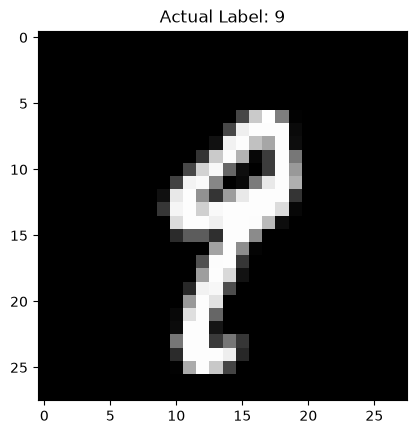

Actual: 9
Predicted: 9


In [39]:
import matplotlib.pyplot as plt

image, label = test_dataset[78]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual Label: {label}")
plt.show()

input_image = image.view(1, -1)

with torch.no_grad():
    output = model(input_image)

prediction = output.argmax(dim=1)

print("Actual:", label)
print("Predicted:", prediction.item())